In [1]:
# ! pip install stopwordsiso
# ! pip install underthesea

In [2]:
import pandas as pd
import numpy as np
import re
import json
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from underthesea import word_tokenize, sent_tokenize, classify, pos_tag, ner
import stopwordsiso

from scipy import stats
from collections import Counter

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 0. Helper functions and global variables

In [3]:
CHAPTER_TOKEN = "[CHAPTER_BREAK]"

In [4]:
# get vietnamese stopwords
stopwords = stopwordsiso.stopwords('vi')

stopwords = {w.replace(" ", "_").replace('-', '_') for w in stopwords}

In [5]:
# function to handle negation 
# in Vietnamese, negation phrases/words are typically preceeded by the word "không"
def handle_negation(tokens):
    new_tokens = []
    i = 0
    # Define punctuation to ignore
    punct = set(string.punctuation)
    
    while i < len(tokens):
        # 1. Check if current word is "không"
        # 2. Check if there is a next token
        # 3. Check if that next token is NOT punctuation
        if (tokens[i] == "không" and 
            i + 1 < len(tokens) and 
            tokens[i+1] not in punct):
            
            # Merge: "không", "vui" -> "không_vui"
            combined_token = f"không_{tokens[i+1]}"
            new_tokens.append(combined_token)
            i += 2  # Skip the next word
        else:
            # Keep as is (either it's not "không", or it's followed by punctuation)
            new_tokens.append(tokens[i])
            i += 1
            
    return new_tokens

In [6]:
# function to clean text
def clean_text(text):
    # Check if this is our special break token first
    if text == CHAPTER_TOKEN:
        return [CHAPTER_TOKEN]

    # named entities recognition
    ner_results = ner(text)

    # remove person entities from tokens to reduce noise
    tokens = [word.lower() for word, pos, chunk, ner_tag in ner_results if 'PER' not in ner_tag]
    # replace white space in tokens with multiple words with and underscore
    tokens = [w.replace(' ', '_') for w in tokens]
    
    tokens = handle_negation(tokens)
    
    # Filter non-words, except for the chapter break token
    tokens = [w for w in tokens if re.search(r'[a-zà-ỹ]', w) or w == CHAPTER_TOKEN]
    
    tokens = [w for w in tokens if w not in stopwords]
    return tokens

In [7]:
# initiate NRCLex with custom lexicon
with open('./data/emotion_lexicon/custom_emotion_lexicon.json', 'r', encoding='utf-8') as f:
    nrc_lexicon = json.load(f)

nrc_lexicon = {key.replace(" ", "_"): value for key, value in nrc_lexicon.items()}

# 1. Load texts and apply preprocessing

In [8]:
# "Sống mòn" by Nam Cao
with open('./data/cleaned/song_mon_nam_cao_stripped.txt', 'r', encoding='utf-8') as f:
    nam = [line.strip() for line in f.readlines()]

# "Ngày mới" by Thạch Lam
with open('./data/cleaned/ngay_moi_thach_lam_stripped.txt', 'r', encoding='utf-8') as f:
    thach = [line.strip() for line in f.readlines()]

# "Số đỏ" by Vũ Trọng Phụng
with open('./data/cleaned/so_do_vu_trong_phung_stripped.txt', 'r', encoding='utf-8') as f:
    vu = [line.strip() for line in f.readlines()]

# "Tắt đèn" by Ngô Tất Tố
with open('./data/cleaned/tat_den_ngo_tat_to_stripped.txt', 'r', encoding='utf-8') as f:
    ngo = [line.strip() for line in f.readlines()]

# "Đoạn tuyệt" by Nhất Linh
with open('./data/cleaned/doan_tuyet_nhat_linh_stripped.txt', 'r', encoding='utf-8') as f:
    nhat = [line.strip() for line in f.readlines()]

# "Bước đường cùng" by Nguyễn Công Hoan
with open('./data/cleaned/buoc_duong_cung_nguyen_cong_hoan_stripped.txt', 'r', encoding='utf-8') as f:
    nguyen = [line.strip() for line in f.readlines()]

In [9]:
# report the number of paragraphs per each novel and average number of tokens after preprocessing
novels = {
    'song_mon': nam,
    'ngay_moi': thach,
    'so_do': vu,
    'tat_den': ngo,
    'doan_tuyet': nhat,
    'buoc_duong_cung': nguyen
}

novels_cleaned = {}

for novel in novels:
    novels_cleaned[novel] = [clean_text(p) for p in novels[novel]]
    print(f"{novel}: {len(novels_cleaned[novel])} paragraphs, median {np.median([len(p) for p in novels_cleaned[novel] if CHAPTER_TOKEN not in p]):.2f} tokens per paragraph")

song_mon: 1607 paragraphs, median 8.00 tokens per paragraph
ngay_moi: 1347 paragraphs, median 8.00 tokens per paragraph
so_do: 2074 paragraphs, median 6.00 tokens per paragraph
tat_den: 1511 paragraphs, median 9.00 tokens per paragraph
doan_tuyet: 2133 paragraphs, median 5.00 tokens per paragraph
buoc_duong_cung: 2272 paragraphs, median 6.00 tokens per paragraph


# 2. Sentiment analysis

## 2.1. Raw emotion scores over the entire work
Report the raw NRCLex emotion scores over the entire work

In [10]:
def analyze_sentiment(tokens, lexicon):
    # Initialize counters
    emotions = {
        'fear': 0, 'anger': 0, 'anticipation': 0, 'trust': 0, 'surprise': 0,
        'sadness': 0, 'disgust': 0, 'joy': 0
    }
    sentiments = {
        'positive': 0, 'negative': 0
    }

    total_tokens = 0

    for token in tokens:
        # Dictionary lookups are O(1) - very fast!
        if token in lexicon:
            entry = lexicon[token]
            total_tokens += 1
            
            # Update emotions if the value is 1
            for emo in emotions:
                if entry.get(emo) == 1:
                    emotions[emo] += 1
            
            # Update sentiments if the value is 1
            for sent in sentiments:
                if entry.get(sent) == 1:
                    sentiments[sent] += 1
                    
    return sentiments, emotions, total_tokens

In [11]:
sentiments = {}
emotions = {}
for novel in novels_cleaned:
    sentiments[novel], emotions[novel] = [], []
    for p in novels_cleaned[novel]:
        if CHAPTER_TOKEN not in p:
            s, e, _ = analyze_sentiment(p, nrc_lexicon)
            sentiments[novel].append(s)
            emotions[novel].append(e)

# 1. Create a list to store the final summary rows
summary_data = []

for novel in novels_cleaned:
    # Convert list of dictionaries to DataFrames
    df_sent = pd.DataFrame(sentiments[novel])
    df_emot = pd.DataFrame(emotions[novel])
    
    # Sum scores for this specific novel
    total_sent = df_sent.sum()
    total_emot = df_emot.sum()
    
    # Combine results into one dictionary for this novel
    # This merges the novel name, sentiment sums, and emotion sums
    novel_summary = {'novel': novel}
    novel_summary.update(total_sent.to_dict())
    novel_summary.update(total_emot.to_dict())
    
    summary_data.append(novel_summary)

# 2. Create the final reporting DataFrame
report_df = pd.DataFrame(summary_data)

# 3. Set novel as index for better viewing
report_df.set_index('novel', inplace=True)

# Display result
display(report_df)

,positive,negative,fear,anger,anticipation,trust,surprise,sadness,disgust,joy
novel,,,,,,,,,,
song_mon,1865,2145,562,556,811,867,406,724,565,964
ngay_moi,1844,1409,366,318,640,1048,259,605,307,1086
so_do,1721,1388,434,391,735,923,304,397,350,790
tat_den,677,753,212,260,330,394,188,220,165,336
doan_tuyet,1191,1163,335,282,545,684,280,452,269,690
buoc_duong_cung,1215,1311,462,451,545,539,255,424,337,547


In [12]:
# the dominant sentiment for each novel
for novel in report_df.index:
    main_sent = report_df.loc[novel, ['positive', 'negative']].idxmax()
    main_emo = report_df.loc[novel, ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'joy']].idxmax()
    print(f"Novel: {novel} - Dominant sentiment: {main_sent}")
    # print(f"    Dominant sentiment: {main_sent}")

Novel: song_mon - Dominant sentiment: negative
Novel: ngay_moi - Dominant sentiment: positive
Novel: so_do - Dominant sentiment: positive
Novel: tat_den - Dominant sentiment: negative
Novel: doan_tuyet - Dominant sentiment: positive
Novel: buoc_duong_cung - Dominant sentiment: negative


## 2.2. Sentiment polarity
Compare the relative weight of positive vs. negative words, ranging between -1 (purely negative) and +1 (purely positive):
$$\text{Polarity} = \frac{\text{Positive} - \text{Negative}}{\text{Positive} + \text{Negative} + \varepsilon}$$

In [13]:
def sentiment_polarity(pos, neg, eps=1e-7):
    return (pos - neg) / (pos + neg + eps)

In [14]:
for novel in report_df.index:
    polarity = sentiment_polarity(report_df.loc[novel, 'positive'], report_df.loc[novel, 'negative'])
    print(f"Novel: {novel} - Sentiment polarity: {polarity:.2f}")

Novel: song_mon - Sentiment polarity: -0.07
Novel: ngay_moi - Sentiment polarity: 0.13
Novel: so_do - Sentiment polarity: 0.11
Novel: tat_den - Sentiment polarity: -0.05
Novel: doan_tuyet - Sentiment polarity: 0.01
Novel: buoc_duong_cung - Sentiment polarity: -0.04


## 2.3. Sentiment over narrative arc
Break novels into chapters and analyze sentiment density and polarity

In [15]:
def group_by_chapter(tokenized_paragraphs):
    chapters = []
    current_chapter = []
    
    for para in tokenized_paragraphs:
        # Check if the paragraph is actually a chapter break
        # (It will be a list containing your special token)
        if len(para) > 0 and para[0] == "[CHAPTER_BREAK]":
            if current_chapter:
                chapters.append(current_chapter)
                current_chapter = []
        else:
            current_chapter.append(para)
            
    # Append the last chapter after the loop ends
    if current_chapter:
        chapters.append(current_chapter)
        
    return chapters


def calculate_chapter_sentiments(chapters, lexicon):
    arc_data = []
    
    for i, chapter in enumerate(chapters):
        # Flatten all tokens in the chapter into one list
        all_tokens = [token for paragraph in chapter for token in paragraph]
        
        # calculate sentiment scores of the chapter
        sentiments, emotions, num_tokens_with_score = analyze_sentiment(all_tokens, lexicon) 
        
        # Calculate Polarity for this chapter
        pos = sentiments.get('positive', 0)
        neg = sentiments.get('negative', 0)
        polarity = sentiment_polarity(pos, neg)

        arc_data.append({
            'chapter': i + 1,
            'total_tokens': len(all_tokens),
            'num_tokens_with_score': num_tokens_with_score,
            'polarity': polarity,
            'positive': sentiments.get('positive', 0),
            'negative': sentiments.get('negative', 0),
            'fear': emotions.get('fear', 0),
            'anger': emotions.get('anger', 0),
            'anticipation': emotions.get('anticipation', 0),
            'trust': emotions.get('trust', 0),
            'surprise': emotions.get('surprise', 0),
            'sadness': emotions.get('sadness', 0),
            'disgust': emotions.get('disgust', 0),
            'joy': emotions.get('joy', 0),
        })
        
    return pd.DataFrame(arc_data)

In [16]:
novel_arcs = {}

for novel in novels_cleaned:
    chapters = group_by_chapter(novels_cleaned[novel])
    novel_arcs[novel] = calculate_chapter_sentiments(chapters, nrc_lexicon)

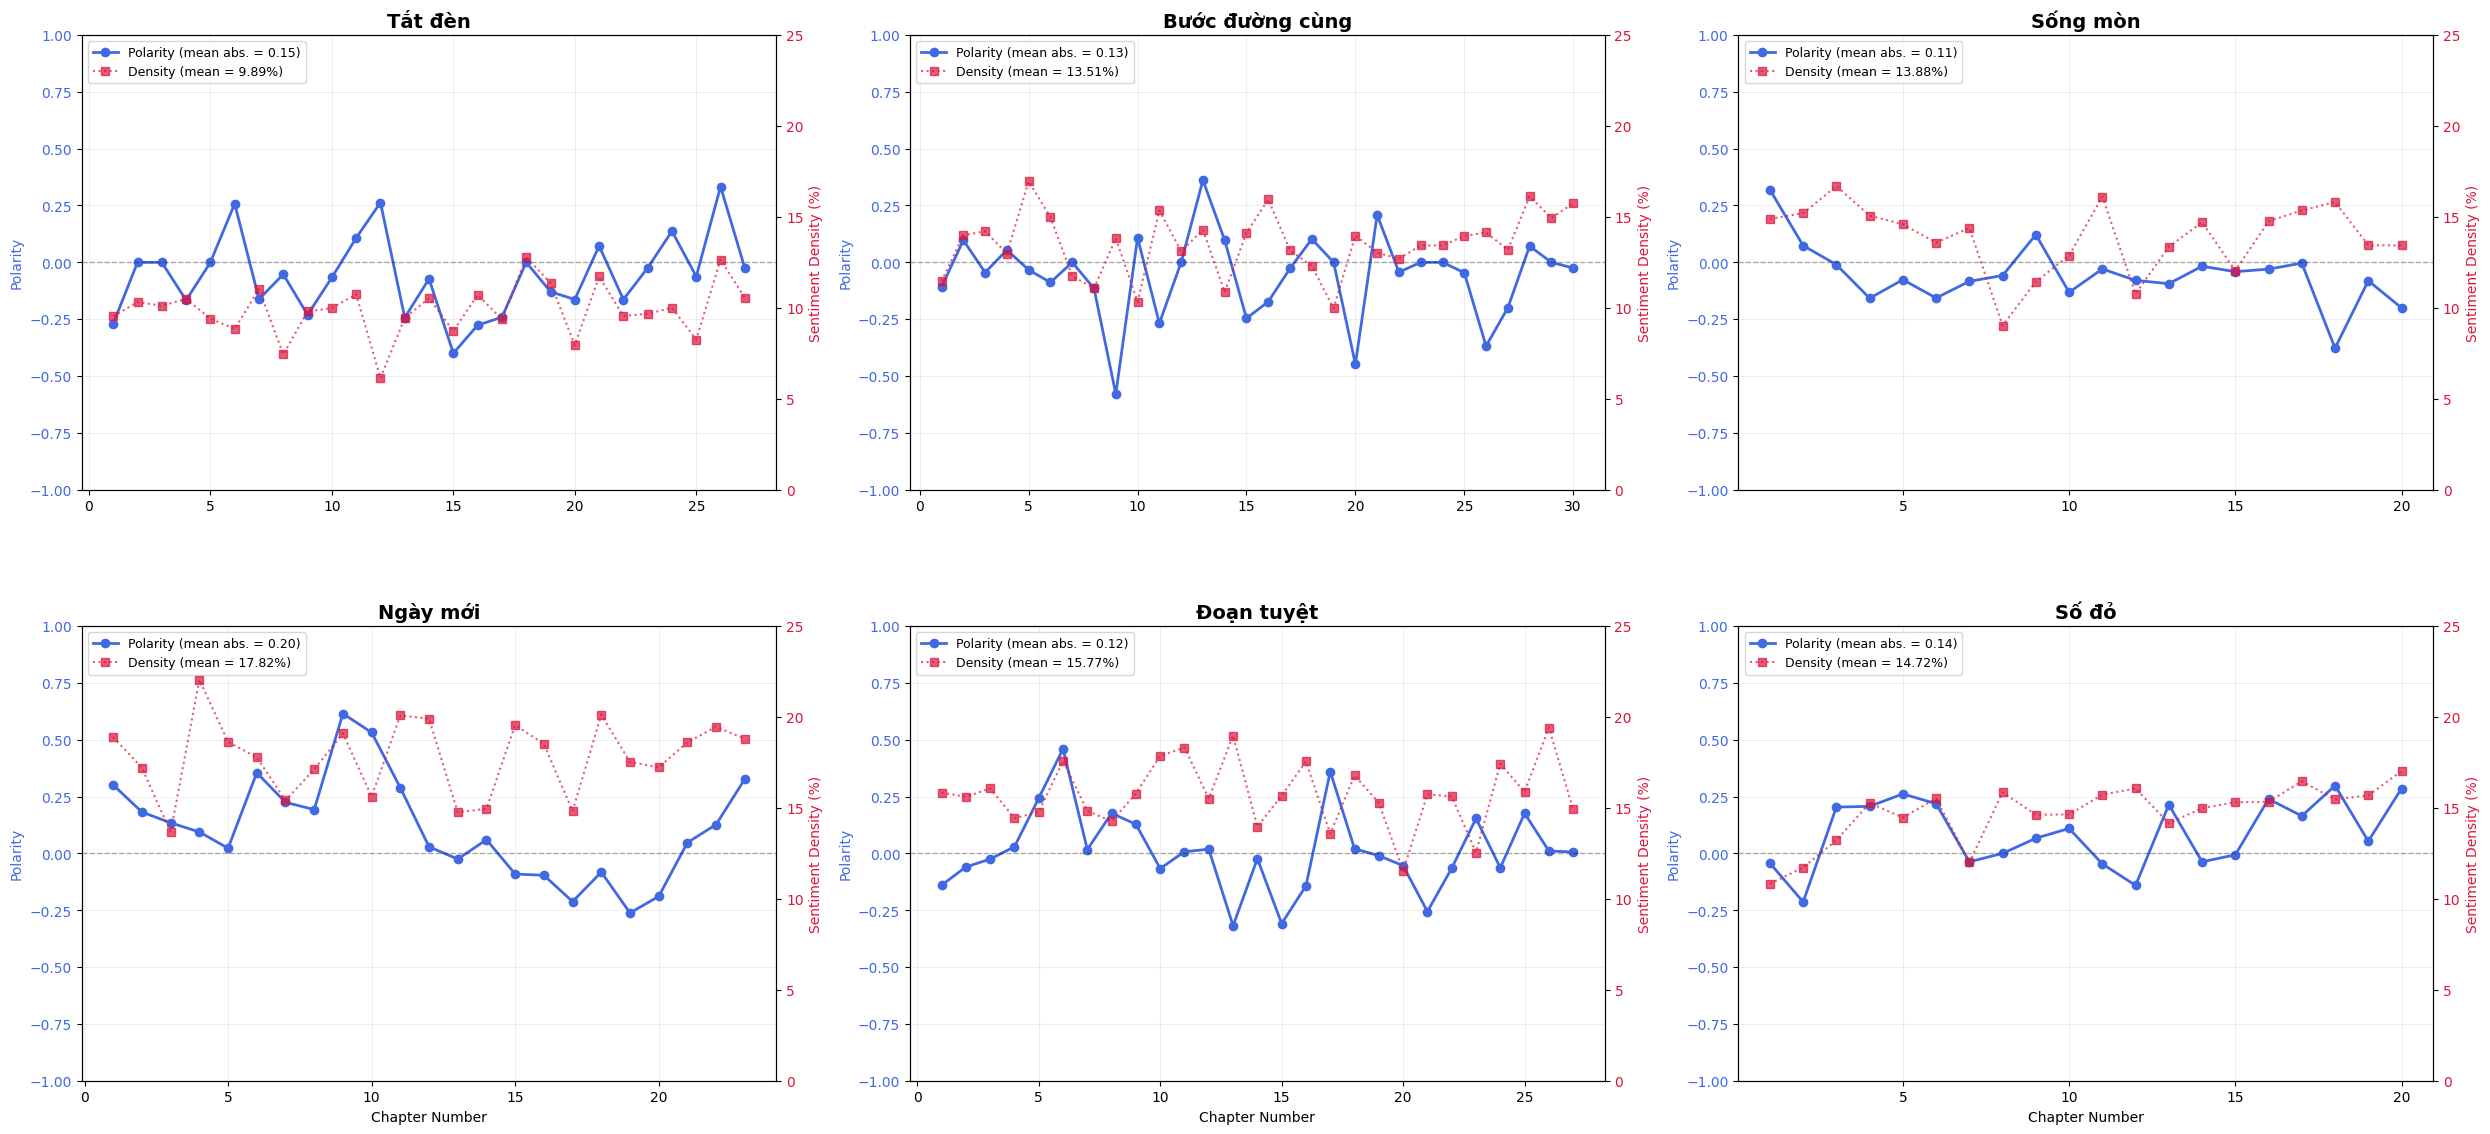

In [17]:
# visualize polarity and sentiment density over time
import matplotlib.ticker as ticker

novel_names = {
    'tat_den': "Tắt đèn",
    'buoc_duong_cung': "Bước đường cùng",
    'song_mon': "Sống mòn",
    'ngay_moi': "Ngày mới",
    'doan_tuyet': "Đoạn tuyệt",
    'so_do': "Số đỏ",
}

# 1. Setup the grid (3 rows, 2 columns)
fig, axes = plt.subplots(2, 3, figsize=(25, 12))
axes = axes.flatten()

# 2. Iterate through your novels
for i, (novel_id, name) in enumerate(novel_names.items()):
    data = novel_arcs[novel_id]
    ax1 = axes[i]
    
    # --- Left Y-Axis: Polarity ---
    color_pol = 'royalblue'
    ax1.set_title(f"{name}", fontsize=14, fontweight='bold')
    ax1.set_ylabel('Polarity', color=color_pol, fontsize=10)
    
    line1 = ax1.plot(data['chapter'], data['polarity'], 
                     marker='o', color=color_pol, label=f'Polarity (mean abs. = {np.mean(data["polarity"].abs()):.2f})', linewidth=2)
    
    ax1.tick_params(axis='y', labelcolor=color_pol)
    # Fixed scale for Polarity
    ax1.set_ylim(-1, 1)
    ax1.axhline(0, color='black', lw=1, ls='--', alpha=0.3)
    ax1.grid(True, alpha=0.2)

    ax1.xaxis.set_major_locator(ticker.MultipleLocator(5))

    # --- Right Y-Axis: Density ---
    ax2 = ax1.twinx()
    color_den = 'crimson'
    ax2.set_ylabel('Sentiment Density (%)', color=color_den, fontsize=10)
    
    # Calculate density percentage
    density = (data['num_tokens_with_score'] / data['total_tokens']) * 100
    
    line2 = ax2.plot(data['chapter'], density, 
                     marker='s', color=color_den, label=f'Density (mean = {np.mean(density):.2f}%)', linestyle=':', alpha=0.7)
    
    ax2.tick_params(axis='y', labelcolor=color_den)
    
    # FIXED: Density limit set to 25% as requested
    ax2.set_ylim(0, 25) 

    # Clean up aesthetics
    if i >= 3:
        ax1.set_xlabel('Chapter Number')
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=9)

# 3. Global formatting
plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.3)

plt.savefig('./fig/narrative_arcs.png', dpi=300)
plt.show()

## 2.4. Identifying emotional "fingerprints"
The Kruskal-Wallis H-test evaluates whether a specific emotion is distributed uniformly across the corpus or if certain novels possess unique emotional profiles.
* $H_0$: The normalized emotion scores for all novels are drawn from the same underlying distribution.
* $H_1$: At least one novel exhibits a statistically distinct distribution of the specified emotion, indicating a unique emotional signature.

In [38]:
from scipy.stats import kruskal

def test_global_emotion_variance(emotion):
    """
    Performs a Kruskal-Wallis H-test to see if a particular emotion varies 
    significantly across all novels in the dataset
    """
    # extract the emotion data
    normalized_scores = []
    for novel, data in novel_arcs.items():
        norm_series = data[emotion] / data['num_tokens_with_score']    # normalize the emotion scores
        normalized_scores.append(norm_series.dropna())

    # number of groups
    k = len(normalized_scores)

    # total sample size
    n = sum(len(group) for group in normalized_scores)

    # run test
    h_stat, p_val = kruskal(*normalized_scores)

    # calculate effect size
    eps_sq = (h_stat - k + 1) / (n - k)

    # print(f"--- Global Kruskal-Wallis Test: {emotion} (Normalized) ---")
    # print(f"H-statistic: {h_stat:.4f}")
    # print(f"p-value:     {p_val:.4f}")
    
    # if p_val < 0.05:
    #     print(f"Result: Significant difference found in {emotion} across novels.")
    # else:
    #     print(f"Result: No significant difference found.")
    return h_stat, p_val, eps_sq

In [39]:
kw_results = []
for emotion in ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'joy']:
    h, p, e = test_global_emotion_variance(emotion)
    kw_results.append((emotion,  h, p, e))

kw_results = pd.DataFrame(kw_results, columns=['emotion', 'h_statistic', 'p_value', 'effect_size'])

kw_results

,emotion,h_statistic,p_value,effect_size
0,fear,23.487756,0.000272,0.131119
1,anger,35.434038,0.000001,0.215844
2,anticipation,6.067675,0.299689,0.007572
3,trust,28.560076,0.000028,0.167093
4,surprise,12.194454,0.032218,0.051024
5,sadness,11.027409,0.050839,0.042748
6,disgust,15.031587,0.010228,0.071146
7,joy,26.457545,0.000073,0.152181


We follow up with a Mann-Whitney U-test to compare novels in a pairwise manner. This specifically tests if the intensity of an emotion in one novel is significantly higher than the other novel.
* $H_0$: The emotional distributions of both novels (A & B) are identical
* $H_1$: The emotional intensity of novel A is greater than novel B

To correct for multiple testing, we use Bonferroni correction, which divide the alpha level by the number of tests conducted.

In [45]:
from scipy.stats import mannwhitneyu,  rankdata
# from itertools import combinations

def cliffs_delta(x, y):
    """
    Cliff's delta: probability difference that x > y vs y > x
    Direction: positive => x tends to be larger than y
    """
    x = np.asarray(x)
    y = np.asarray(y)

    n1 = len(x)
    n2 = len(y)

    ranks = rankdata(np.concatenate([x, y]))
    r1 = np.sum(ranks[:n1])

    delta = (2 * r1 - n1 * (n1 + 1)) / (n1 * n2) - 1
    return delta

def run_one_tailed_comparison(target_emotion):
    """
    Runs one-tailed Mann-Whitney U tests to identify if one novel 
    has a significantly higher emotional intensity than another.
    """
    results = []
    novel_names = list(novel_arcs.keys())
    num_tests = len(novel_names) * (len(novel_names) - 1)

    alpha=0.05
    bonferroni_threshold = alpha/num_tests
    
    # Compare every possible pair
    for n1 in novel_names:
        for n2 in novel_names:
            if n1 != n2:
                # 1. Normalize scores (Current score / tokens with score)
                dist1 = (novel_arcs[n1][target_emotion] / (novel_arcs[n1]['num_tokens_with_score'] + 1e-6)).dropna()
                dist2 = (novel_arcs[n2][target_emotion] / (novel_arcs[n2]['num_tokens_with_score'] + 1e-6)).dropna()
                
                # 2. Run one-tailed test (alternative='greater' checks if dist1 > dist2)
                stat, p_val = mannwhitneyu(dist1, dist2, alternative='greater')
        
                # 3. Adjusted p-value
                adjusted_p_val = min(p_val * num_tests, 1.0)

                # 4. Cliff's delta (same direction as hypothesis)
                delta = cliffs_delta(dist1, dist2)
                
                results.append({
                    'Novel_A': n1,
                    'Novel_B': n2,
                    'U-statistic': stat,
                    'p_value': p_val,
                    'adjusted_p_value': adjusted_p_val,
                    'effect_size': delta,
                    'significant': p_val < bonferroni_threshold,
                })

    print(f"Total tests performed: {num_tests}")
    print(f"Original Alpha: {alpha} | Bonferroni Threshold: {bonferroni_threshold:.4f}")
    
    return pd.DataFrame(results)

In [46]:
res = run_one_tailed_comparison('joy')
res[res['significant']==True]

Total tests performed: 30
Original Alpha: 0.05 | Bonferroni Threshold: 0.0017


,Novel_A,Novel_B,U-statistic,p_value,adjusted_p_value,effect_size,significant
5,ngay_moi,song_mon,357.0,0.001034,0.031031,0.552174,True
7,ngay_moi,tat_den,496.0,0.000158,0.004754,0.597424,True
9,ngay_moi,buoc_duong_cung,595.0,0.000004,0.000113,0.724638,True


Overall, "Ngày mới" by Thạch Lam appears to be "happier" (more joyous) than other works.

In [47]:
# res = run_one_tailed_comparison('sadness')
# res[res['significant']==True]

All novels conveys the same sadness intensity

In [48]:
res = run_one_tailed_comparison('anger')
res[res['significant']==True]

Total tests performed: 30
Original Alpha: 0.05 | Bonferroni Threshold: 0.0017


,Novel_A,Novel_B,U-statistic,p_value,adjusted_p_value,effect_size,significant
16,tat_den,ngay_moi,499.0,0.000126,0.003790,0.607085,True
18,tat_den,doan_tuyet,563.0,0.000307,0.009206,0.544582,True
26,buoc_duong_cung,ngay_moi,575.0,0.000019,0.000571,0.666667,True
29,buoc_duong_cung,doan_tuyet,652.0,0.000041,0.001224,0.609877,True


Regarding anger intensity, "Tắt đèn" by Ngô Tất Tố and "Bước đường cùng" by Nguyễn Công Hoan conveys more anger intensity than "Ngày mới" by Thạch Lam and "Đoạn tuyệt". This is quite interesting because while Tắt đèn and Bước đường cùng's narratives revolve around the peasant and slave classes, Ngày mới and Đoạn Tuyệt's protagonists are intellectuals (impoverished in the case of Trường from Ngày mới and progressive in the case of Đoạn tuyệt)

In [49]:
res = run_one_tailed_comparison('disgust')
res[res['significant']==True]

Total tests performed: 30
Original Alpha: 0.05 | Bonferroni Threshold: 0.0017


,Novel_A,Novel_B,U-statistic,p_value,adjusted_p_value,effect_size,significant


In [50]:
res = run_one_tailed_comparison('fear')
res[res['significant']==True]

Total tests performed: 30
Original Alpha: 0.05 | Bonferroni Threshold: 0.0017


,Novel_A,Novel_B,U-statistic,p_value,adjusted_p_value,effect_size,significant
25,buoc_duong_cung,song_mon,462.0,0.000691,0.020739,0.540000,True
26,buoc_duong_cung,ngay_moi,584.0,0.000009,0.000280,0.692754,True
29,buoc_duong_cung,doan_tuyet,598.0,0.001047,0.031406,0.476543,True


Regarding fear, "Bước đường cùng" also exhibits higher emotional intensity than works featuring the intecllectuals like Sống mòn, Ngày mới, and Đoạn tuyệt

In [51]:
res = run_one_tailed_comparison('anticipation')
res[res['significant']==True]

Total tests performed: 30
Original Alpha: 0.05 | Bonferroni Threshold: 0.0017


,Novel_A,Novel_B,U-statistic,p_value,adjusted_p_value,effect_size,significant


In [52]:
res = run_one_tailed_comparison('trust')
res[res['significant']==True]

Total tests performed: 30
Original Alpha: 0.05 | Bonferroni Threshold: 0.0017


,Novel_A,Novel_B,U-statistic,p_value,adjusted_p_value,effect_size,significant
5,ngay_moi,song_mon,375.0,0.000217,0.006511,0.630435,True
9,ngay_moi,buoc_duong_cung,576.0,0.000018,0.000529,0.669565,True
10,so_do,song_mon,311.0,0.001399,0.041979,0.555000,True
14,so_do,buoc_duong_cung,491.0,0.000081,0.002424,0.636667,True
24,doan_tuyet,buoc_duong_cung,607.0,0.000640,0.019199,0.498765,True


In [54]:
res = run_one_tailed_comparison('surprise')
res[res['significant']==True]

Total tests performed: 30
Original Alpha: 0.05 | Bonferroni Threshold: 0.0017


,Novel_A,Novel_B,U-statistic,p_value,adjusted_p_value,effect_size,significant


Works featuring the intellectuals like "Ngày mới" and "Đoạn tuyệt" features a higher intensity of trust than "Bước đường cùng", "Sống mòn" (ft. improverished intellectuals who are socially alienated). Interestingly, "Số đỏ" by Vũ Trọng Phụng, featuring a mixture of urban underclass, urban petty bourgeoisie, and pseudo-intellectual/progressive characters also features a high intensity of trust here compared to these works.

## 2.5. Emotional transitions and narrative rhythm
While static averages reveal what emotions are present, they fail to capture the narrative logic of how one feeling leads to another. This section employs Markov Chain analysis to map the "emotional grammar" of each novel. By calculating a transition matrix at a granular level, we can quantify the probability of moving between specific emotional states. This approach identifies the rhythmic "pulse" of the prose, distinguishing authors who favor rapid emotional shifts from those who cultivate lingering, sustained moods.

In [55]:
def compute_transition_matrix(texts, lexicon):
    """
    Computes a transition matrix based only on paragraphs with identified 
    emotional content, ignoring neutral gaps between emotional events.
    """
    texts = [t for t in texts if t != [CHAPTER_TOKEN]]
    emotion_keys = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 
                    'sadness', 'disgust', 'joy']
    
    emotion_sequence = []
    current_mood = None

    for tokens in texts:
        _, emotions, total_scored = analyze_sentiment(tokens, lexicon)
        
        # Determine dominant emotion if content exists
        if any(count > 0 for count in emotions.values()):
            current_mood = max(emotions, key=emotions.get)
            emotion_sequence.append(current_mood)

    # Initialize matrix
    df = pd.DataFrame(0.0, index=emotion_keys, columns=emotion_keys)

    # Fill transition counts
    for i in range(len(emotion_sequence) - 1):
        current_state = emotion_sequence[i]
        next_state = emotion_sequence[i+1]
        df.loc[current_state, next_state] += 1

    # Normalize to probabilities
    matrix_prob = df.div(df.sum(axis=1), axis=0).fillna(0)
    
    return matrix_prob

In [56]:
def plot_transition_heatmap(matrix, title=None):
    """
    Plots the transition matrix as a heatmap.
    """
    plt.figure(figsize=(10, 8))
    
    # Create the heatmap
    sns.heatmap(matrix, 
                annot=True,      # Show probability values
                fmt=".2f",       # Format to 2 decimal places
                cmap="YlGnBu",   # Color scheme (Yellow-Green-Blue)
                cbar_kws={'label': 'Transition Probability'},
                square=True)
    
    plt.title("Emotional Transition Matrix: " + title, fontsize=15, pad=20)
    plt.xlabel("Next Paragraph Emotion", fontsize=12)
    plt.ylabel("Current Paragraph Emotion", fontsize=12)
    
    plt.tight_layout()
    # plt.savefig(f"{title.lower().replace(' ', '_')}.png")
    plt.show() # Uncomment if running in a local notebook

In [57]:
def get_top_transitions(matrix, top_n=5):
    """
    Extracts the most frequent emotional transitions from a normalized matrix.
    """
    transitions = []
    for current_emo in matrix.index:
        for next_emo in matrix.columns:
            prob = matrix.loc[current_emo, next_emo]
            if prob > 0:
                transitions.append((current_emo, next_emo, prob))
    
    # Sort by probability and return top N
    return sorted(transitions, key=lambda x: x[2], reverse=True)[:top_n]

/tmp/ipykernel_671/3901210834.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


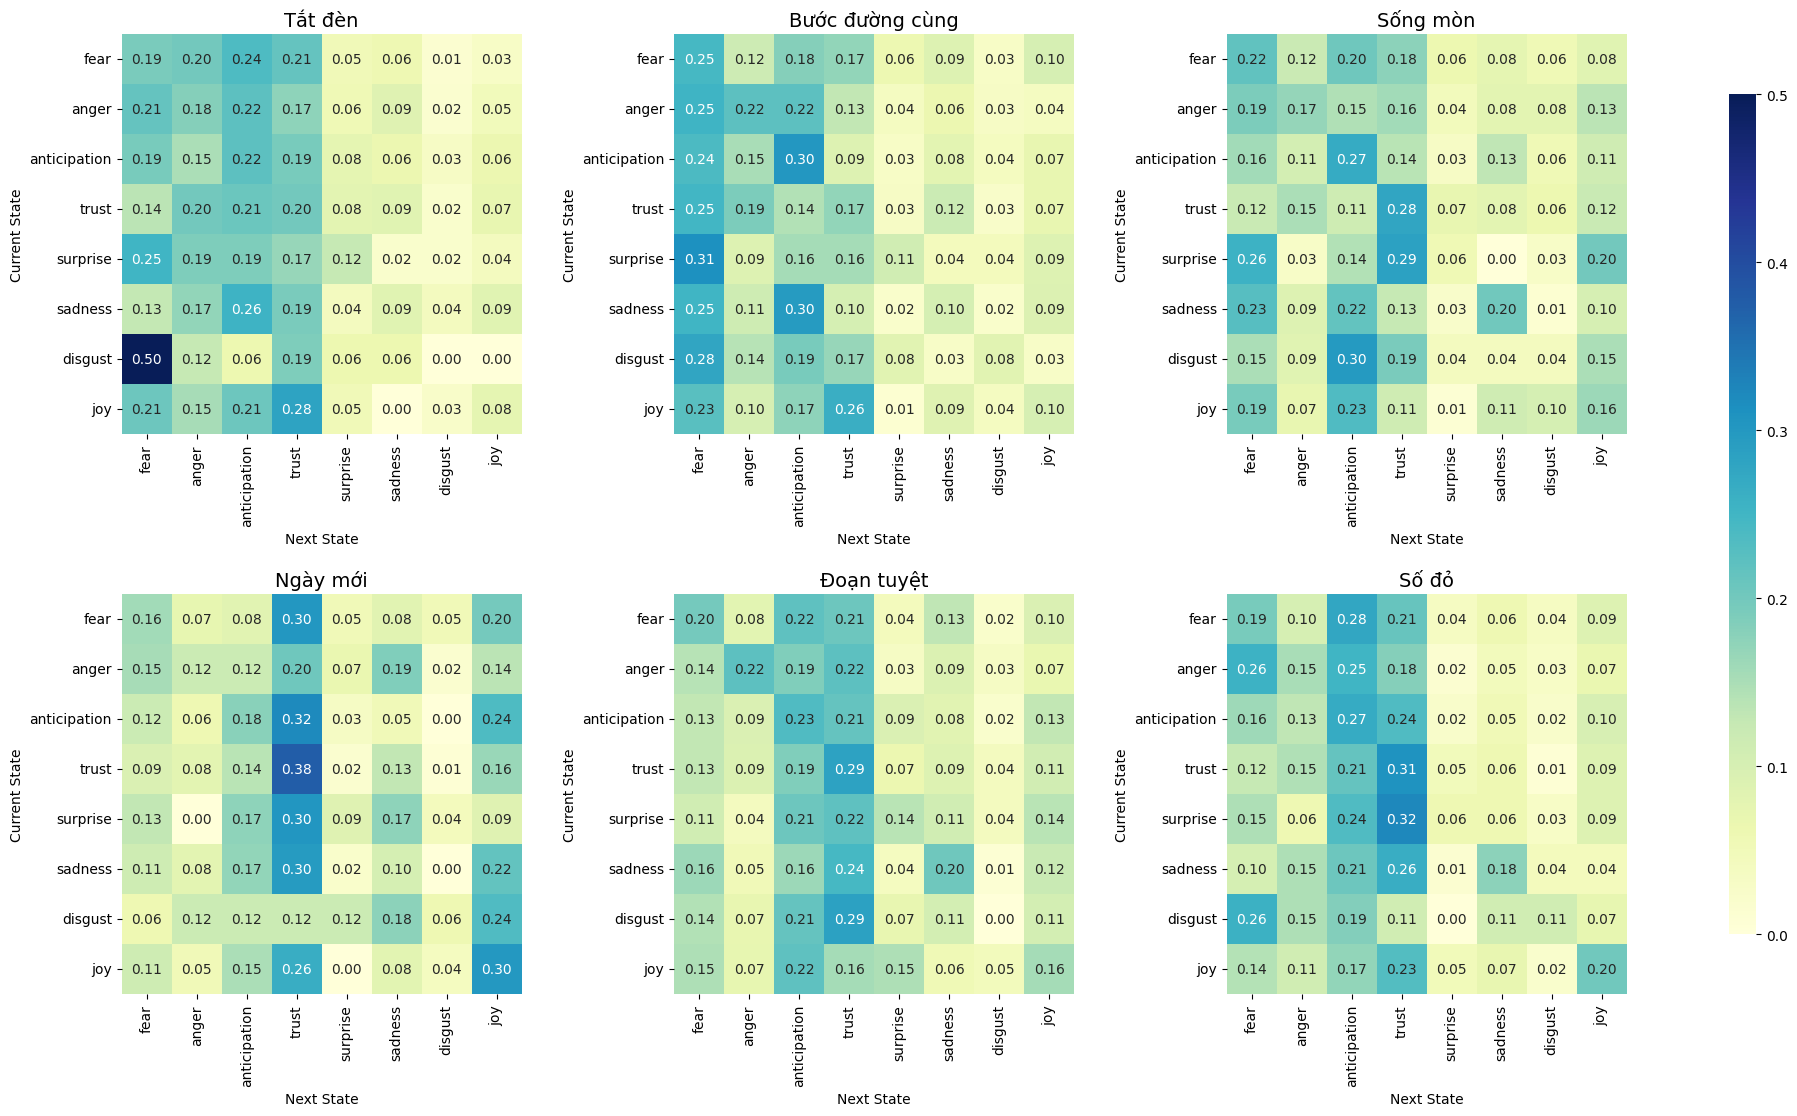

In [71]:
novel_names = {
    'tat_den': "Tắt đèn",
    'buoc_duong_cung': "Bước đường cùng",
    'song_mon': "Sống mòn",
    'ngay_moi': "Ngày mới",
    'doan_tuyet': "Đoạn tuyệt",
    'so_do': "Số đỏ",
}

# 1. Setup the grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Define the shared color bar axis [left, bottom, width, height]
cbar_ax = fig.add_axes([0.95, 0.15, 0.015, 0.7])

# 2. Iterate through novels
for i, (novel_id, name) in enumerate(novel_names.items()):
    # Compute the matrix (assuming this function is defined in your environment)
    novel_matrix = compute_transition_matrix(novels_cleaned[novel_id], nrc_lexicon)
    
    # Use vmin and vmax to fix the color scale across all plots
    sns.heatmap(novel_matrix,
                annot=True,      
                fmt=".2f",       
                cmap="YlGnBu",   
                vmin=0, vmax=0.5,  
                square=True,
                ax=axes[i],
                cbar=(i == 0),   
                cbar_ax=cbar_ax if i == 0 else None, # Assign only once
                annot_kws={"size": 10})

    axes[i].set_title(name, fontsize=14)
    axes[i].set_xlabel("Next State")
    axes[i].set_ylabel("Current State")

# 3. Global formatting
plt.tight_layout()
plt.subplots_adjust(top=0.90, bottom=0.1, left=0.05, right=0.90, hspace=0.4, wspace=0.3)
plt.savefig('./fig/emotional_transition.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Topic modeling

In [37]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel, LdaMulticore
from gensim.models.ldamodel import CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

from sklearn.model_selection import ParameterGrid
from tqdm import tqdm

In [38]:
def prepare_chapters_for_lda(tokenized_chapters):
    """
    Flattens a list of chapters (lists of paragraphs) into a 
    list of token lists for LDA processing.
    """
    flat_chapters = []
    
    for chapter in tokenized_chapters:
        # Flatten the list of paragraphs into one single list of tokens
        chapter_tokens = [token for paragraph in chapter for token in paragraph]
        
        # Only add chapters that have actual content
        if len(chapter_tokens) > 0:
            flat_chapters.append(chapter_tokens)
            
    return flat_chapters

In [39]:
def prepare_corpus_dictionary_for_lda(novel, no_above=0.8, no_below=2):
    chapters = group_by_chapter(novels_cleaned[novel])
    chapters = prepare_chapters_for_lda(chapters)

    # create dictionary
    dictionary = Dictionary(chapters)
    # filter out extremely rare and common words 
    dictionary.filter_extremes(no_above=no_above, no_below=no_below)
    corpus = [dictionary.doc2bow(text) for text in chapters]

    return dictionary, corpus, chapters

In [50]:
# set up param grid for tuning
param_grid = {
    'num_topics': [3, 4, 5],
    'alpha': [0.25, 0.5, 1.0, 2.0, 5.0],    # controls how many topics appear per document
    'eta': [0.5, 1.0, 5.0],      # controls how many words dominate each topic
    'passes': [10, 15],
}

grid = list(ParameterGrid(param_grid))

print(f"Number of parameter combinations: {len(grid)}")

Number of parameter combinations: 90


In [51]:
def run_hyperparameter_tuning(corpus, dictionary, chapters, grid):
    results = []
    for params in tqdm(grid, desc='Tuning LDA'):
        # train the model with the configuration
        lda_model = LdaMulticore(
            corpus = corpus,
            id2word=dictionary,
            num_topics=params['num_topics'],
            alpha=params['alpha'],
            eta=params['eta'],
            random_state=111,
            passes=params['passes'],
            workers=None,    # use all but 1 CPU core to speed up training
        )
    
        # calculate coherence 
        coherence_model = CoherenceModel(
            model=lda_model,
            texts=chapters,
            dictionary=dictionary,
            coherence='c_v'
        )
    
        cv_score = coherence_model.get_coherence()
    
        # calculate topic distribution
        doc_dist = []
        for bow in corpus:
            # get full distribution
            dist = lda_model.get_document_topics(bow, minimum_probability=0)
            probs = [p for _, p in dist]
            doc_dist.append(probs)
        doc_dist = np.array(doc_dist)
        
        # document-topic sparsity (mean entropy) - effect of alpha
        doc_entropy = -np.sum(doc_dist * np.log(doc_dist + 1e-12), axis=1)
        mean_doc_entropy = doc_entropy.mean()
    
        # Topic-word sparsity - effect of eta
        topic_word_dist = lda_model.get_topics()  # shape: (k, vocab_size)
        topic_entropy = -np.sum(topic_word_dist * np.log(topic_word_dist + 1e-12), axis=1)
        mean_topic_entropy = topic_entropy.mean()
        
        # Store results
        results.append({
            **params,
            'coherence_cv': cv_score,
            'mean_doc_entropy': mean_doc_entropy,
            'mean_topic_entropy': mean_topic_entropy,
        })
    
    # 3. View results
    results_df = pd.DataFrame(results).sort_values(by='coherence_cv', ascending=False)
    return results_df

In [52]:
# rebuild the model with the best params
def build_lda_model(novel, grid, no_above=0.9, no_below=5):
    # initialize dictionary and corpus for lda
    dictionary, corpus, chapters = prepare_corpus_dictionary_for_lda(novel, no_above, no_below)
    # run hyperparam tuning
    results_df = run_hyperparameter_tuning(corpus, dictionary, chapters, grid)
    
    best_idx = results_df['coherence_cv'].idxmax()
    best_params = results_df[['alpha', 'eta', 'num_topics', 'passes']].loc[best_idx].to_dict()
    print(f"Retraining model with best parameters: {best_params}")
    
    lda_model = LdaMulticore(
        corpus = corpus,
        id2word=dictionary,
        num_topics=best_params['num_topics'],
        alpha=best_params['alpha'],
        eta=best_params['eta'],
        random_state=111,
        passes=int(best_params['passes']),
        workers=None,    # use all but 1 CPU core to speed up training
    )
    
    # Prepare the visualization
    vis = gensimvis.prepare(lda_model, corpus, dictionary)
    return lda_model, vis

## 3.1. "Sống mòn" - Nam Cao

In [53]:
model, vis = build_lda_model('song_mon', grid)

Tuning LDA: 100%|███████████████████████████████████████████████████████████████████████| 90/90 [01:20<00:00,  1.12it/s]

Retraining model with best parameters: {'alpha': 2.0, 'eta': 5.0, 'num_topics': 4.0, 'passes': 10.0}


In [54]:
pyLDAvis.enable_notebook()
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.029341  0.001596       1        1  82.386136
0      0.003857 -0.008928       2        1  12.086301
2      0.011041  0.007235       3        1   4.436767
3      0.014442  0.000097       4        1   1.090795, topic_info=        Term       Freq      Total Category  logprob  loglift
34       chủ  45.000000  45.000000  Default  30.0000  30.0000
218   trường  79.000000  79.000000  Default  29.0000  29.0000
366      thư  48.000000  48.000000  Default  28.0000  28.0000
31      chết  67.000000  67.000000  Default  27.0000  27.0000
347     nước  48.000000  48.000000  Default  26.0000  26.0000
..       ...        ...        ...      ...      ...      ...
159     ngồi   0.230951  70.422496   Topic4  -6.6582  -1.2018
280      đứa   0.229822  84.891658   Topic4  -6.6631  -1.3936
161  nhà_quê   0.227218  51.696277   Topic4  -6.6745  -0.9090
424      cơm   0.228203  90.506779   Topic4  -6.6702  -1.4647
279       đủ   0.226988  61.014464   Topic4  -6.6755  -1.0757

[298 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
407       1  0.620408    bao
407       2  0.310204    bao
407       3  0.077551    bao
732       1  0.843919  buồng
732       2  0.067514  buồng
...     ...       ...    ...
281       2  0.049810   đứng
281       3  0.016603   đứng
405       1  0.779812   ầm_ĩ
405       2  0.194953   ầm_ĩ
405       3  0.097477   ầm_ĩ

[582 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 1, 3, 4])

## 3.2. "Ngày mới" - Thạch Lam

In [55]:
model, vis = build_lda_model('ngay_moi', grid)
pyLDAvis.enable_notebook()
vis

Tuning LDA: 100%|███████████████████████████████████████████████████████████████████████| 90/90 [01:18<00:00,  1.15it/s]

Retraining model with best parameters: {'alpha': 5.0, 'eta': 0.5, 'num_topics': 5.0, 'passes': 10.0}


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.029376  0.065600       1        1  37.369856
1      0.057342 -0.037032       2        1  25.165991
4     -0.079835 -0.037426       3        1  16.488106
3      0.039096  0.036074       4        1  16.111443
2      0.012773 -0.027216       5        1   4.864604, topic_info=     Term        Freq       Total Category  logprob  loglift
197  nàng  365.000000  365.000000  Default  30.0000  30.0000
237    ta   74.000000   74.000000  Default  29.0000  29.0000
586  vườn   34.000000   34.000000  Default  28.0000  28.0000
86    hoa   42.000000   42.000000  Default  27.0000  27.0000
289    vợ   59.000000   59.000000  Default  26.0000  26.0000
..    ...         ...         ...      ...      ...      ...
101   học    2.727743   60.060444   Topic5  -5.2933  -0.0687
332  buổi    2.666675   59.611178   Topic5  -5.3159  -0.0838
257  tiền    2.222331   45.972863   Topic5  -5.4982  -0.0063
208  phía    2.172852   40.400632   Topic5  -5.5207   0.1004
44    câu    2.095579   54.083375   Topic5  -5.5569  -0.2275

[303 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
557       1  0.358453  an_lâm
557       2  0.102415  an_lâm
557       3  0.256038  an_lâm
557       4  0.204830  an_lâm
557       5  0.076811  an_lâm
...     ...       ...     ...
649       1  0.752051      ẵm
649       2  0.107436      ẵm
654       1  0.721018      ốm
654       2  0.090127      ốm
654       4  0.090127      ốm

[1001 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 5, 4, 3])

## 3.3. "Số đỏ" - Vũ Trọng Phụng

In [56]:
model, vis = build_lda_model('so_do', grid)
pyLDAvis.enable_notebook()
vis

Tuning LDA: 100%|███████████████████████████████████████████████████████████████████████| 90/90 [01:18<00:00,  1.15it/s]

Retraining model with best parameters: {'alpha': 2.0, 'eta': 1.0, 'num_topics': 3.0, 'passes': 10.0}


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.046198  0.030817       1        1  42.235747
2      0.013295 -0.044747       2        1  39.411725
0     -0.059493  0.013930       3        1  18.352528, topic_info=         Term        Freq       Total Category  logprob  loglift
525  mỹ_thuật   32.000000   32.000000  Default  30.0000  30.0000
62         cụ  238.000000  238.000000  Default  29.0000  29.0000
213      thầy  103.000000  103.000000  Default  28.0000  28.0000
361      ngài  128.000000  128.000000  Default  27.0000  27.0000
9         báo   35.000000   35.000000  Default  26.0000  26.0000
..        ...         ...         ...      ...      ...      ...
21        bọn   11.428477   45.167378   Topic3  -5.2723   0.3211
257       xem   12.796958   70.465618   Topic3  -5.1592  -0.0105
258       xin   12.819488   75.552550   Topic3  -5.1574  -0.0785
156        mẹ   11.973463   63.014440   Topic3  -5.2257   0.0347
461    phụ_nữ   10.439106   34.979097   Topic3  -5.3628   0.4862

[199 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
302       1  0.313544  !_anh
302       2  0.209030  !_anh
302       3  0.522574  !_anh
643       1  0.133920  !_khổ
643       2  0.803519  !_khổ
...     ...       ...    ...
641       2  0.439511    đốc
641       3  0.293007    đốc
300       1  0.386765    đời
300       2  0.569969    đời
300       3  0.020356    đời

[456 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 1])

## 3.4. "Tắt đèn" - Ngô Tất Tố

In [57]:
model, vis = build_lda_model('tat_den', grid)
pyLDAvis.enable_notebook()
vis

Tuning LDA: 100%|███████████████████████████████████████████████████████████████████████| 90/90 [01:13<00:00,  1.22it/s]

Retraining model with best parameters: {'alpha': 5.0, 'eta': 0.5, 'num_topics': 4.0, 'passes': 15.0}


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.090458  0.056196       1        1  28.476516
2      0.085132  0.032428       2        1  25.062505
1      0.033645 -0.003016       3        1  24.174328
3     -0.028318 -0.085607       4        1  22.286651, topic_info=          Term       Freq       Total Category  logprob  loglift
300        chó  91.000000   91.000000  Default  30.0000  30.0000
204       cháu  79.000000   79.000000  Default  29.0000  29.0000
78   lý_trưởng  96.000000   96.000000  Default  28.0000  28.0000
383          u  44.000000   44.000000  Default  27.0000  27.0000
470        tao  36.000000   36.000000  Default  26.0000  26.0000
..         ...        ...         ...      ...      ...      ...
193       đứng  14.405627   62.269982   Topic4  -4.9738   0.0373
256      thằng  16.044617  117.235081   Topic4  -4.8660  -0.4876
171         ăn  14.108038   70.464721   Topic4  -4.9947  -0.1072
208      chồng  12.570392   83.464118   Topic4  -5.1101  -0.3919
204       cháu  12.297004   79.390172   Topic4  -5.1321  -0.3638

[242 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
394       1  0.739686   !_em
394       2  0.123281   !_em
394       3  0.123281   !_em
394       4  0.123281   !_em
0         1  0.078000  !_ông
...     ...       ...    ...
442       3  0.676325     ốm
442       4  0.112721     ốm
290       2  0.248593   —_bà
290       3  0.124296   —_bà
290       4  0.621482   —_bà

[673 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 3, 2, 4])

## 3.5. "Đoạn tuyệt" - Nhất Linh

In [58]:
model, vis = build_lda_model('doan_tuyet', grid)
pyLDAvis.enable_notebook()
vis

Tuning LDA: 100%|███████████████████████████████████████████████████████████████████████| 90/90 [01:14<00:00,  1.21it/s]

Retraining model with best parameters: {'alpha': 0.25, 'eta': 5.0, 'num_topics': 5.0, 'passes': 15.0}


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.037923  0.000026       1        1  93.025324
1      0.008643 -0.006493       2        1   5.096734
4      0.007957  0.003253       3        1   1.612852
3      0.008518  0.002314       4        1   0.197601
2      0.012804  0.000900       5        1   0.067488, topic_info=         Term        Freq       Total Category  logprob  loglift
108        mẹ  112.000000  112.000000  Default  30.0000  30.0000
25      chồng  165.000000  165.000000  Default  29.0000  29.0000
47   gia_đình   66.000000   66.000000  Default  28.0000  28.0000
19      chàng   68.000000   68.000000  Default  27.0000  27.0000
170     tiếng   85.000000   85.000000  Default  26.0000  26.0000
..        ...         ...         ...      ...      ...      ...
96        lắm    0.012738   56.790144   Topic5  -6.3291  -1.1015
290        me    0.012736   37.521171   Topic5  -6.3293  -0.6873
208   đưa_mắt    0.012734   42.471282   Topic5  -6.3294  -0.8113
211       đầu    0.012730   46.679516   Topic5  -6.3297  -0.9061
11       bước    0.012728   41.298602   Topic5  -6.3299  -0.7838

[329 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
2         1  0.886552   bay
2         2  0.098506   bay
221       1  0.805431  buộc
221       2  0.201358  buộc
7         1  0.967295   báo
...     ...       ...   ...
550       2  0.113942    đỗ
465       1  0.969019   đứa
465       2  0.018635   đứa
218       1  0.960523  đứng
218       2  0.029107  đứng

[365 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 5, 4, 3])

## 3.6. "Bước đường cùng" - Nguyễn Công Hoan

In [59]:
model, vis = build_lda_model('buoc_duong_cung', grid)
pyLDAvis.enable_notebook()
vis

Tuning LDA: 100%|███████████████████████████████████████████████████████████████████████| 90/90 [01:23<00:00,  1.08it/s]

Retraining model with best parameters: {'alpha': 5.0, 'eta': 0.5, 'num_topics': 3.0, 'passes': 15.0}


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.063675 -0.052872       1        1  43.225807
0     -0.082926 -0.022987       2        1  29.670164
2      0.019251  0.075858       3        1  27.104029, topic_info=          Term        Freq       Total Category  logprob  loglift
37         chị  323.000000  323.000000  Default  30.0000  30.0000
336        tao  146.000000  146.000000  Default  29.0000  29.0000
653       thuế   66.000000   66.000000  Default  28.0000  28.0000
420  lý_trưởng   72.000000   72.000000  Default  27.0000  27.0000
505       nghị  126.000000  126.000000  Default  26.0000  26.0000
..         ...         ...         ...      ...      ...      ...
193        tay   23.215089   80.935037   Topic3  -5.0855   0.0566
167        pha   23.552335   91.005949   Topic3  -5.0711  -0.0462
242        đâu   22.464712   91.843985   Topic3  -5.1184  -0.1027
122        mày   23.809146  170.656604   Topic3  -5.0603  -0.6641
37         chị   21.881345  323.594429   Topic3  -5.1447  -1.3884

[213 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
1         1  0.168726  anh_em
1         2  0.801450  anh_em
1         3  0.042182  anh_em
5         1  0.890262      bu
5         2  0.111283      bu
...     ...       ...     ...
256       2  0.143770    đồng
256       3  0.560704    đồng
258       1  0.709098     đội
258       2  0.052526     đội
258       3  0.236366     đội

[474 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 1, 3])